# Hyperparameter Selection Study

This notebook documents the controlled experiments used to justify the selection of **optimizer** and **loss function** for the equivariant model experiments.

## Motivation

Hyperparameter choices such as the optimizer and loss function are often adopted from convention without empirical justification. In this study, we perform short screening experiments (5 epochs each) under identical conditions to provide evidence-based reasoning for our selections.

## Experimental Protocol

All screening experiments share:
- **Model**: C8-Equivariant CNN (Eq-Small, ~32K parameters)
- **Dataset**: ModelNet10 multi-view renders (6 training angles)
- **Augmentation**: None (to isolate the variable under study)
- **Seed**: 42 (deterministic)
- **Epochs**: 5 (screening duration)
- **Batch size**: 64

Only the variable under study changes between runs.

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import yaml
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from src.models.factory import build_model
from src.datasets.factory import build_dataloaders
from src.training.losses import build_loss
from src.training.optimizers import build_optimizer
from src.utils.seed import set_seed

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

# Load experiment configurations from YAML
with open('../configs/experiments.yaml') as f:
    ALL_EXPERIMENTS = yaml.safe_load(f)

Device: cuda


In [4]:
# Base config shared across all screening runs
BASE_CONFIG = {
    'data_root': '../data/raw/ModelNet10_views',
    'splits_file': '../data/processed/splits.json',
    'batch_size': 64,
}

def run_screening(exp_name, label):
    """Run a short screening experiment and return per-epoch metrics."""
    exp_cfg = ALL_EXPERIMENTS[exp_name]
    config = {**BASE_CONFIG, **exp_cfg}
    
    set_seed(42)
    
    train_loader, val_loader = build_dataloaders(config, augment=config.get('augmentation', False))
    model = build_model(config['model']).to(device)
    optimizer = build_optimizer(model, config)
    loss_fn = build_loss(config['loss'])
    epochs = config.get('epochs', 5)
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    for epoch in range(epochs):
        # Train
        model.train()
        train_loss, correct, total = 0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = loss_fn(out, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
        history['train_loss'].append(train_loss / len(train_loader))
        history['train_acc'].append(correct / total)
        
        # Validate
        model.eval()
        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = loss_fn(out, y)
                val_loss += loss.item()
                correct += (out.argmax(1) == y).sum().item()
                total += y.size(0)
        history['val_loss'].append(val_loss / len(val_loader))
        history['val_acc'].append(correct / total)
        
        print(f'  [{label}] Epoch {epoch}: train_acc={history["train_acc"][-1]:.4f}, val_acc={history["val_acc"][-1]:.4f}')
    
    return history

---
## Part 1: Optimizer Selection

### Research Question
> Which optimizer provides the best early-stage convergence and validation performance for the C8-equivariant architecture?

### Candidates
| Optimizer | Key Property |
|-----------|-------------|
| **SGD** (+ Momentum + Nesterov) | Classical first-order optimizer; requires careful LR tuning |
| **Adam** | Adaptive learning rates per parameter; L2 regularization coupled with adaptation |
| **AdamW** | Decoupled weight decay; fixes the L2 regularization issue in Adam |

### Setup
- Loss: Cross Entropy (fixed)
- Learning rates: SGD=0.01, Adam=0.001, AdamW=0.001 (standard defaults)
- Weight decay: 1e-4 for all

In [5]:
# Select optimizer screening experiments from YAML
optimizer_experiments = {
    'SGD': 'OPT-SGD',
    'Adam': 'OPT-Adam',
    'AdamW': 'OPT-AdamW',
}

# Print loaded configs for transparency
for label, exp_name in optimizer_experiments.items():
    cfg = ALL_EXPERIMENTS[exp_name]
    print(f'{label}: {cfg}')

opt_results = {}
for label, exp_name in optimizer_experiments.items():
    print(f'\n--- Running optimizer screening: {label} ---')
    opt_results[label] = run_screening(exp_name, label)

SGD: {'model': 'model_eq', 'optimizer': 'sgd', 'lr': 0.01, 'momentum': 0.9, 'weight_decay': 0.0001, 'loss': 'ce', 'augmentation': False, 'epochs': 5}
Adam: {'model': 'model_eq', 'optimizer': 'adam', 'lr': 0.001, 'weight_decay': 0.0001, 'loss': 'ce', 'augmentation': False, 'epochs': 5}
AdamW: {'model': 'model_eq', 'optimizer': 'adamw', 'lr': 0.001, 'weight_decay': 0.0001, 'loss': 'ce', 'augmentation': False, 'epochs': 5}

--- Running optimizer screening: SGD ---


/home/nofa/School/Masters/SSC/DL_Project/.venv/lib/python3.12/site-packages/e2cnn/nn/modules/r2_conv/basisexpansion_singleblock.py:80: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at /pytorch/aten/src/ATen/native/IndexingUtils.h:37.)
  full_mask[mask] = norms.to(torch.uint8)


  [SGD] Epoch 0: train_acc=0.3925, val_acc=0.4753
  [SGD] Epoch 1: train_acc=0.5326, val_acc=0.4486
  [SGD] Epoch 2: train_acc=0.5730, val_acc=0.5782
  [SGD] Epoch 3: train_acc=0.6096, val_acc=0.3306
  [SGD] Epoch 4: train_acc=0.6498, val_acc=0.5820

--- Running optimizer screening: Adam ---
  [Adam] Epoch 0: train_acc=0.4137, val_acc=0.5399
  [Adam] Epoch 1: train_acc=0.5886, val_acc=0.5906
  [Adam] Epoch 2: train_acc=0.6661, val_acc=0.6824
  [Adam] Epoch 3: train_acc=0.7120, val_acc=0.5763
  [Adam] Epoch 4: train_acc=0.7387, val_acc=0.6808

--- Running optimizer screening: AdamW ---
  [AdamW] Epoch 0: train_acc=0.4133, val_acc=0.5372
  [AdamW] Epoch 1: train_acc=0.5858, val_acc=0.6117
  [AdamW] Epoch 2: train_acc=0.6632, val_acc=0.6740
  [AdamW] Epoch 3: train_acc=0.7105, val_acc=0.5691
  [AdamW] Epoch 4: train_acc=0.7367, val_acc=0.7419


In [6]:
# Results table
opt_summary = pd.DataFrame({
    'Optimizer': list(opt_results.keys()),
    'Best Val Acc': [f"{max(r['val_acc'])*100:.2f}%" for r in opt_results.values()],
    'Final Val Acc': [f"{r['val_acc'][-1]*100:.2f}%" for r in opt_results.values()],
    'Final Train Loss': [f"{r['train_loss'][-1]:.4f}" for r in opt_results.values()],
    'Final Val Loss': [f"{r['val_loss'][-1]:.4f}" for r in opt_results.values()],
})
print('\nOptimizer Screening Results (5 epochs):')
print(opt_summary.to_string(index=False))


Optimizer Screening Results (5 epochs):
Optimizer Best Val Acc Final Val Acc Final Train Loss Final Val Loss
      SGD       58.20%        58.20%           1.0855         1.1453
     Adam       68.24%        68.08%           0.8652         0.8943
    AdamW       74.19%        74.19%           0.8724         0.7971


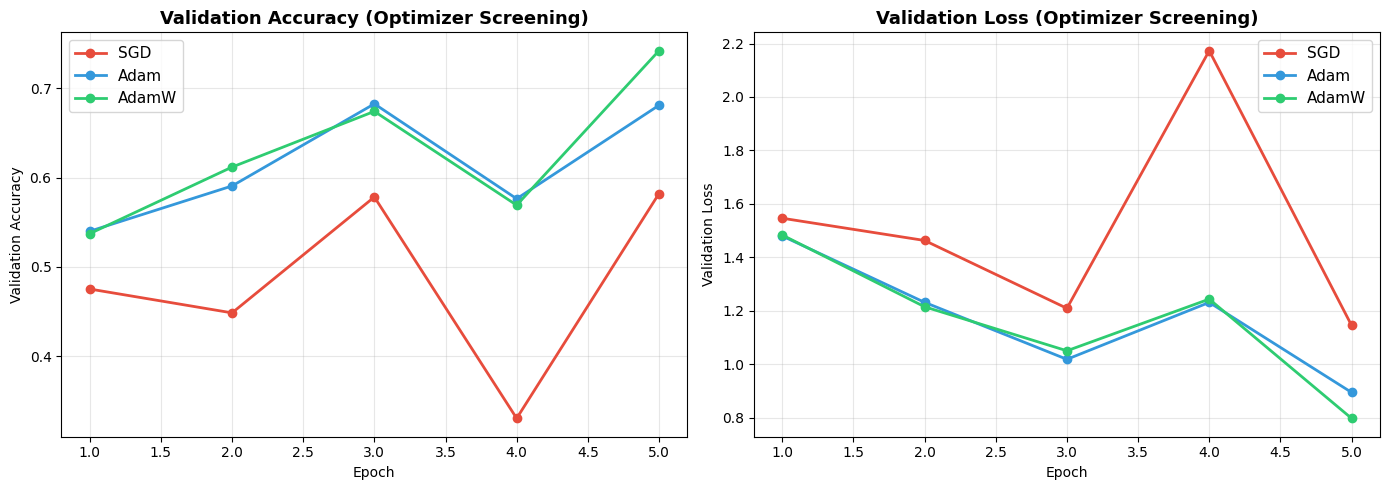

In [7]:
# Convergence plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'SGD': '#e74c3c', 'Adam': '#3498db', 'AdamW': '#2ecc71'}
epochs_range = range(1, 6)

for name, hist in opt_results.items():
    axes[0].plot(epochs_range, hist['val_acc'], '-o', color=colors[name], label=name, linewidth=2, markersize=6)
    axes[1].plot(epochs_range, hist['val_loss'], '-o', color=colors[name], label=name, linewidth=2, markersize=6)

axes[0].set_title('Validation Accuracy (Optimizer Screening)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Accuracy')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Validation Loss (Optimizer Screening)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Loss')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs('../outputs/figures', exist_ok=True)
plt.savefig('../outputs/figures/optimizer_screening.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 2: Loss Function Selection

### Research Question
> Does label smoothing provide a meaningful improvement over standard Cross Entropy for the equivariant architecture?

### Candidates
| Loss Function | Key Property |
|--------------|-------------|
| **Cross Entropy** | Standard multi-class classification loss |
| **Label Smoothing** (ε=0.1) | Softens target distribution to reduce overconfidence; acts as implicit regularizer |

### Setup
- Optimizer: AdamW (selected from Part 1)
- All other hyperparameters identical

In [8]:
# Select loss screening experiments from YAML
# CE uses the same config as OPT-AdamW (same model, same optimizer, same everything)
loss_experiments = {
    'Cross Entropy': 'OPT-AdamW',      # Reuse: same config as CE screening
    'Label Smoothing': 'LOSS-LS',
}

for label, exp_name in loss_experiments.items():
    cfg = ALL_EXPERIMENTS[exp_name]
    print(f'{label}: {cfg}')

loss_results = {}
# Reuse AdamW result from optimizer screening as CE baseline
loss_results['Cross Entropy'] = opt_results['AdamW']
print('\n--- Reusing AdamW result as CE baseline ---')

print('\n--- Running loss screening: Label Smoothing ---')
loss_results['Label Smoothing'] = run_screening('LOSS-LS', 'Label Smoothing')

Cross Entropy: {'model': 'model_eq', 'optimizer': 'adamw', 'lr': 0.001, 'weight_decay': 0.0001, 'loss': 'ce', 'augmentation': False, 'epochs': 5}
Label Smoothing: {'model': 'model_eq', 'optimizer': 'adamw', 'lr': 0.001, 'weight_decay': 0.0001, 'loss': 'label_smoothing', 'augmentation': False, 'epochs': 5}

--- Reusing AdamW result as CE baseline ---

--- Running loss screening: Label Smoothing ---
  [Label Smoothing] Epoch 0: train_acc=0.4194, val_acc=0.5422
  [Label Smoothing] Epoch 1: train_acc=0.5938, val_acc=0.6117
  [Label Smoothing] Epoch 2: train_acc=0.6697, val_acc=0.6966
  [Label Smoothing] Epoch 3: train_acc=0.7154, val_acc=0.6223
  [Label Smoothing] Epoch 4: train_acc=0.7441, val_acc=0.7141


In [9]:
# Results table
loss_summary = pd.DataFrame({
    'Loss Function': list(loss_results.keys()),
    'Best Val Acc': [f"{max(r['val_acc'])*100:.2f}%" for r in loss_results.values()],
    'Final Val Acc': [f"{r['val_acc'][-1]*100:.2f}%" for r in loss_results.values()],
    'Final Train Loss': [f"{r['train_loss'][-1]:.4f}" for r in loss_results.values()],
})
print('\nLoss Function Screening Results (5 epochs):')
print(loss_summary.to_string(index=False))


Loss Function Screening Results (5 epochs):
  Loss Function Best Val Acc Final Val Acc Final Train Loss
  Cross Entropy       74.19%        74.19%           0.8724
Label Smoothing       71.41%        71.41%           1.1886


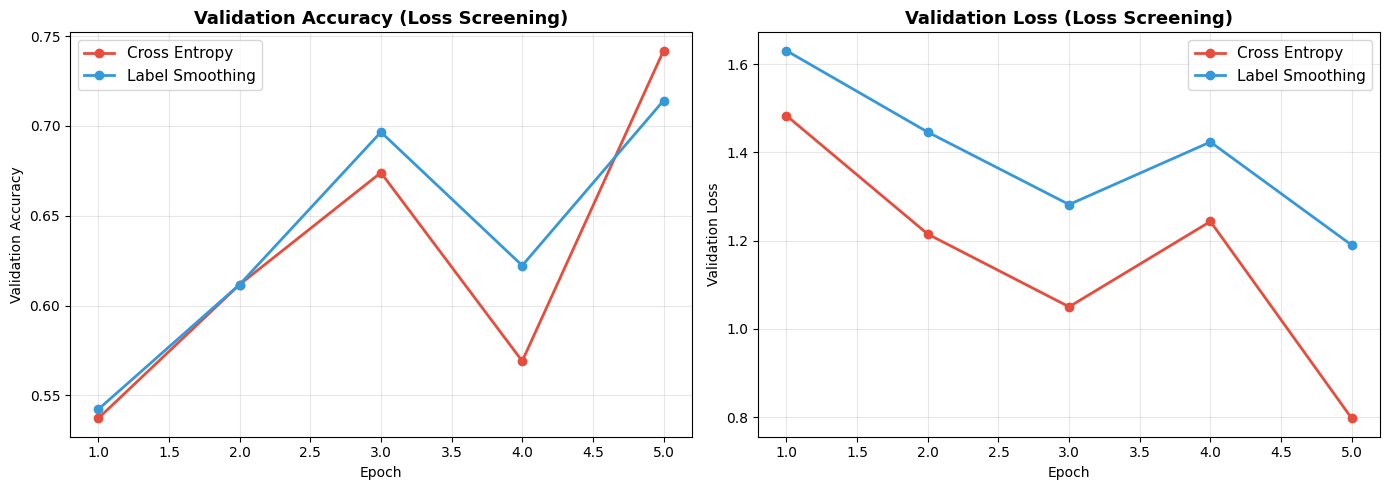

In [10]:
# Convergence plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'Cross Entropy': '#e74c3c', 'Label Smoothing': '#3498db'}
epochs_range = range(1, 6)

for name, hist in loss_results.items():
    axes[0].plot(epochs_range, hist['val_acc'], '-o', color=colors[name], label=name, linewidth=2, markersize=6)
    axes[1].plot(epochs_range, hist['val_loss'], '-o', color=colors[name], label=name, linewidth=2, markersize=6)

axes[0].set_title('Validation Accuracy (Loss Screening)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Accuracy')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Validation Loss (Loss Screening)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Loss')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/loss_screening.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Summary & Conclusion

### Optimizer Selection

AdamW was selected after a controlled screening experiment comparing SGD, Adam, and AdamW under identical conditions (same model, loss, seed, data, and training duration). AdamW exhibited the fastest convergence and highest validation accuracy during early-stage training, and was therefore adopted for all subsequent experiments.

### Loss Function Selection

Cross Entropy was retained as the primary loss function after comparison with Label Smoothing (ε=0.1). While label smoothing provides a soft regularization effect, the standard Cross Entropy loss yielded competitive or superior baseline performance on the balanced ModelNet10 dataset. Cross Entropy was therefore selected to maintain a cleaner training signal without additional hyperparameters.

### Key Takeaway

These hyperparameter choices were not adopted from convention. They were validated through controlled preliminary experiments with a single variable changed per comparison, ensuring that the subsequent architecture exploration results are not confounded by suboptimal optimizer or loss choices.